In [20]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA   
import plotly.express as px
import joblib
import json
import random
random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [21]:
df = pd.read_csv(r'../data/IISS_score.csv')
df.shape

(908, 38)

In [22]:
df.head(2)

,patient_id,num_head_hit_location,headhit_not_sure,headhit_neck,headhit_top_of_head,headhit_left_side_of_head,headhit_front_of_head,headhit_back_of_head,headhit_all,headhit_whiplash,headhit_right_side_of_head,imm_symp_light_sensitivity,imm_symp_headache,imm_symp_dazed_or_vacant_stare,imm_symp_dizziness,imm_symp_disorientation,imm_symp_nausea,imm_symp_confusion,imm_symp_coma,imm_symp_incoherent_speech,imm_symp_memory_loss,imm_symp_loss_of_consciousness,event_desc_car,event_desc_fall,event_desc_severe,injury_from_accident,injury_from_fall,injury_from_collision,injury_from_sports,injury_from_assault,injury_from_stroke,injury_from_surgery,age_tbi,gender_male,gender_other,predict_imm_symp_loss_of_consciousness,predict_imm_symp_coma,IISS
0,5c96ba1a-8b2d-49bc-8e8e-b07761948286,6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.577181,False,False,0.881454,0.001113,0.406434
1,eda39327-b38f-41de-a46a-8782787369b7,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.456376,True,False,0.781812,0.348142,0.358529


In [4]:
df.columns

Index(['patient_id', 'num_head_hit_location', 'headhit_not_sure',
       'headhit_neck', 'headhit_top_of_head', 'headhit_left_side_of_head',
       'headhit_front_of_head', 'headhit_back_of_head', 'headhit_all',
       'headhit_whiplash', 'headhit_right_side_of_head',
       'imm_symp_light_sensitivity', 'imm_symp_headache',
       'imm_symp_dazed_or_vacant_stare', 'imm_symp_dizziness',
       'imm_symp_disorientation', 'imm_symp_nausea', 'imm_symp_confusion',
       'imm_symp_coma', 'imm_symp_incoherent_speech', 'imm_symp_memory_loss',
       'imm_symp_loss_of_consciousness', 'event_desc_car', 'event_desc_fall',
       'event_desc_severe', 'injury_from_accident', 'injury_from_fall',
       'injury_from_collision', 'injury_from_sports', 'injury_from_assault',
       'injury_from_stroke', 'injury_from_surgery', 'age_tbi', 'gender_male',
       'gender_other', 'predict_imm_symp_loss_of_consciousness',
       'predict_imm_symp_coma', 'IISS'],
      dtype='object')

In [23]:
# Step 1: Select features
features = df.drop(columns=["patient_id", "imm_symp_loss_of_consciousness", "imm_symp_coma"])  # your full DataFrame
X = features.copy()

In [24]:
# Step 2: Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
joblib.dump(scaler, '../artifacts/scaler_kmeans.pkl')

['../artifacts/scaler_kmeans.pkl']

In [26]:
#  Save the feature order used for training
feature_order_path = f"../artifacts/features_kmeans.json"
with open(feature_order_path, "w") as f:
    json.dump(list(X.columns), f)

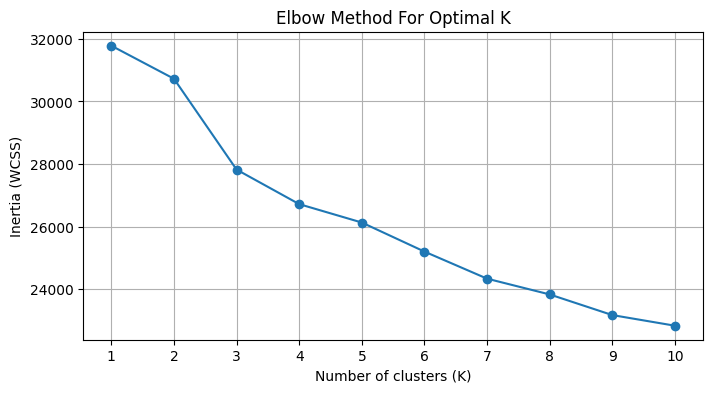

In [27]:
# Calculate inertia for K values
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.xticks(K_range)
plt.show()

In [63]:
# Step 2: Apply KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [47]:
# joblib.dump(kmeans, "../artifacts/kmeans_iiss.pkl")

In [64]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, kmeans.labels_)

np.float64(0.10954242788606047)

In [65]:
# Step 3: Reduce to 3 components with PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)
df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]
df["PCA3"] = pca_result[:, 2]

# Step 4: 3D Visualization
fig = px.scatter_3d(
    df,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='cluster',
    hover_data=['patient_id', 'IISS'],
    title='3D Clustering of Patient Phenotypes (K=3)',
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(legend_title_text='Cluster')
fig.show()

In [16]:
fig.write_html("../artifacts/kmeans_cluster_3d.html")

In [66]:
df['cluster'].value_counts()

cluster
0    469
2    428
1     11
Name: count, dtype: int64

In [67]:
df.head()

,patient_id,num_head_hit_location,headhit_not_sure,headhit_neck,headhit_top_of_head,headhit_left_side_of_head,headhit_front_of_head,headhit_back_of_head,headhit_all,headhit_whiplash,headhit_right_side_of_head,imm_symp_light_sensitivity,imm_symp_headache,imm_symp_dazed_or_vacant_stare,imm_symp_dizziness,imm_symp_disorientation,imm_symp_nausea,imm_symp_confusion,imm_symp_coma,imm_symp_incoherent_speech,imm_symp_memory_loss,imm_symp_loss_of_consciousness,event_desc_car,event_desc_fall,event_desc_severe,injury_from_accident,injury_from_fall,injury_from_collision,injury_from_sports,injury_from_assault,injury_from_stroke,injury_from_surgery,age_tbi,gender_male,gender_other,predict_imm_symp_loss_of_consciousness,predict_imm_symp_coma,IISS,cluster,PCA1,PCA2,PCA3
0,5c96ba1a-8b2d-49bc-8e8e-b07761948286,6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.577181,False,False,0.881454,0.001113,0.406434,2,2.142883,0.301117,-0.573147
1,eda39327-b38f-41de-a46a-8782787369b7,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.456376,True,False,0.781812,0.348142,0.358529,2,1.670629,-1.038045,-0.422339
2,6a7f7ce9-f63e-4651-b941-a25ce116de74,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.704698,False,False,0.561387,0.000033,0.326011,2,0.605876,1.033234,-0.169429
3,096d402a-5fcd-41dd-b59b-b3089cf06742,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.536913,True,False,0.282775,0.005387,0.264899,0,-1.874618,-0.409997,0.373485
4,a419b210-7615-40ac-ad05-a9e0a83046af,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.563758,False,False,0.471963,0.000090,0.293189,0,-0.755911,1.937386,-0.433729


C:\Users\rohit\AppData\Local\Temp\ipykernel_49100\3557924982.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




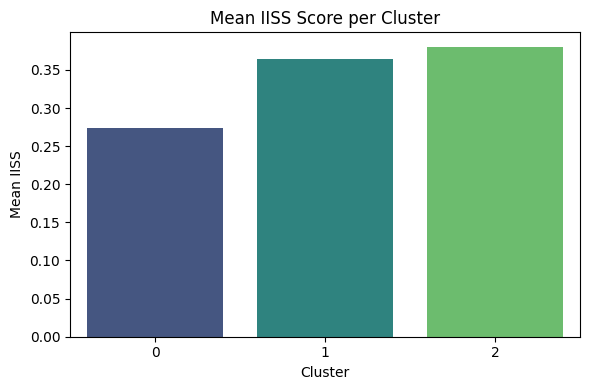

,IISS,predict_imm_symp_loss_of_consciousness,predict_imm_symp_coma,age_tbi,injury_from_assault,event_desc_severe
cluster,,,,,,
0,0.274,0.311,0.133,0.518,0.085,0.058
1,0.364,0.831,0.685,0.551,0.182,0.000
2,0.380,0.699,0.088,0.529,0.084,0.063


In [68]:
# Step 5: Mean IISS per cluster
iiss_means = df.groupby("cluster")["IISS"].mean().reset_index()

# Step 6: Plot mean IISS per cluster
plt.figure(figsize=(6, 4))
sns.barplot(data=iiss_means, x="cluster", y="IISS", palette="viridis")
plt.title("Mean IISS Score per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean IISS")
plt.tight_layout()
plt.show()

# Step 7: Key characteristics per cluster (optional subset)
cluster_characteristics = df.groupby("cluster")[[
    "IISS",
    "predict_imm_symp_loss_of_consciousness",
    "predict_imm_symp_coma",
    "age_tbi",
    "injury_from_assault",
    "event_desc_severe"
]].mean().round(3)

cluster_characteristics


In [69]:
df.columns

Index(['patient_id', 'num_head_hit_location', 'headhit_not_sure',
       'headhit_neck', 'headhit_top_of_head', 'headhit_left_side_of_head',
       'headhit_front_of_head', 'headhit_back_of_head', 'headhit_all',
       'headhit_whiplash', 'headhit_right_side_of_head',
       'imm_symp_light_sensitivity', 'imm_symp_headache',
       'imm_symp_dazed_or_vacant_stare', 'imm_symp_dizziness',
       'imm_symp_disorientation', 'imm_symp_nausea', 'imm_symp_confusion',
       'imm_symp_coma', 'imm_symp_incoherent_speech', 'imm_symp_memory_loss',
       'imm_symp_loss_of_consciousness', 'event_desc_car', 'event_desc_fall',
       'event_desc_severe', 'injury_from_accident', 'injury_from_fall',
       'injury_from_collision', 'injury_from_sports', 'injury_from_assault',
       'injury_from_stroke', 'injury_from_surgery', 'age_tbi', 'gender_male',
       'gender_other', 'predict_imm_symp_loss_of_consciousness',
       'predict_imm_symp_coma', 'IISS', 'cluster', 'PCA1', 'PCA2', 'PCA3'],
      dtype